# **Job Matching Analysis (EDA)**
**Objectives** : The objective of this notebook is to prepare and analyze candidate and job posting datasets for an AI-based job matching system.

**Methodolgy:** Hybrid Job Matching Training Method

The hybrid job matching model combines rule-based filtering with semantic similarity to rank job postings for each candidate. Instead of relying on a single feature, the model integrates multiple matching signals to improve recommendation quality.

**Importing Libraries**






In [ ]:
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [ ]:
candidate_path = kagglehub.dataset_download("ckshetty/candidate-job-role-dataset")
job_path = kagglehub.dataset_download("arshkon/linkedin-job-postings")
print("Dataset downloaded to:", candidate_path,job_path)
print(candidate_path)
print(os.listdir(candidate_path))
print(os.listdir(job_path))

100%|██████████| 5.41k/5.41k [00:00<00:00, 7.94MB/s]

Extracting files...


Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
Dataset downloaded to: /root/.cache/kagglehub/datasets/ckshetty/candidate-job-role-dataset/versions/1 /kaggle/input/linkedin-job-postings
/root/.cache/kagglehub/datasets/ckshetty/candidate-job-role-dataset/versions/1
['candidate_job_role_dataset.csv']
['companies', 'mappings', 'jobs', 'postings.csv']


**Loading the Datasets**

**1.Candidate Job Role Dataset** : Provides structured candidate information such as skills, preferred job role, education, and experience, which is used to build candidate profiles.

**2.LinkedIn Job Postings Dataset** : Contains real-world job postings with job titles, descriptions, required skills, locations, and employment details, making the job matching realistic.

In [ ]:
import pandas as pd
import os
candidate_df = pd.read_csv(os.path.join(candidate_path,"candidate_job_role_dataset.csv"))
candidate_df.head()

,candidate_id,skills,qualification,experience_level,job_role
0,1,"Python, SQL, TensorFlow, Machine Learning, Com...",Master's in Data Science,Senior,Data Scientist
1,2,"HTML, CSS, JavaScript, React, Teamwork",Bachelor's in Computer Science,Mid,Frontend Developer
2,3,"Java, Spring, SQL, REST APIs, Problem Solving",Bachelor's in Software Engineering,Senior,Backend Developer
3,4,"Figma, Adobe XD, UI/UX Design, Creativity",Bachelor's in Design,Entry,Designer
4,5,"Python, Django, JavaScript, React, Agile",Master's in Computer Science,Mid,Full Stack Python Developer


## Feature Description

| Feature | Data Type | Description |
|---------|-----------|-------------|
| **candidate_id** | Integer | Unique identifier assigned to each candidate. Used as a primary key and does not contribute to model learning. |
| **skills** | Text (Categorical/String) | Contains the candidate's technical and soft skills, separated by commas (e.g., Python, SQL, TensorFlow, Teamwork). This feature can be processed using text encoding or vectorization techniques. |
| **qualification** | Categorical | Represents the candidate's highest educational qualification (e.g., Bachelor's in Computer Science, Master's in Data Science). |
| **experience_level** | Categorical | Indicates the candidate's level of work experience, such as **Entry**, **Mid**, or **Senior**. |
| **job_role** | Categorical (Target Variable) | Specifies the candidate's job role (e.g., Data Scientist, Frontend Developer, Backend Developer, Designer). This is the target variable for the classification model. |


In [ ]:
job_df = pd.read_csv(os.path.join(job_path,"postings.csv"))
job_df.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


## Feature Description

| Feature | Data Type | Description |
|---------|-----------|-------------|
| **job_id** | Integer | Unique identifier assigned to each job posting. Serves as the primary key and is not used for predictive modeling. |
| **company_name** | Categorical (String) | Name of the company offering the job position. |
| **title** | Text (String) | Title or designation of the job (e.g., Sales Manager, Software Engineer). |
| **description** | Text (String) | Detailed description of the job responsibilities, requirements, qualifications, and other relevant information. |
| **location** | Categorical (String) | Geographic location where the job is offered (city, state, or country). |
| **formatted_work_type** | Categorical | Human-readable work arrangement, such as **Full-time**, **Part-time**, **Contract**, or **Internship**. |
| **application_type** | Categorical | Specifies how candidates apply for the job (e.g., **OffsiteApply**, **SimpleApply**). |
| **formatted_experience_level** | Categorical | Human-readable experience level required for the job, such as **Entry level**, **Associate**, **Mid-Senior level**, or **Executive**. |
| **skills_desc** | Text (String) | Text describing the required technical and soft skills for the job. This field may contain missing values. |
| **listed_time** | Integer (Timestamp) | Unix timestamp indicating when the job posting was listed. Can be converted into a date-time format for temporal analysis. |
| **work_type** | Categorical | Standardized work type, such as **FULL_TIME**, **PART_TIME**, **CONTRACT**, etc. |
| **compensation_type** | Categorical | Type of compensation offered, such as **BASE_SALARY**. |
| **normalized_salary** | Numeric (Float) | Standardized salary value converted into a common scale to facilitate salary comparison across different pay periods. |

### **EDA for Candidates Datasets**


**1. Dataset Summary Statistics for Candidates**

In [ ]:
# Shape
print("Dataset Shape:", candidate_df.shape)

Dataset Shape: (1000, 5)


In [ ]:
# Summary statistics
candidate_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
candidate_id,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
skills,1000,98,"PHP, Laravel, MySQL, JavaScript",25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qualification,1000,17,Bachelor's in Computer Science,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_level,1000,4,Mid,401,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_role,1000,22,Mobile Developer,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Experience Level:** Candidates are categorized into 4 experience levels (e.g.,
Entry, Junior, Mid, Senior). The Mid-level category is the largest, containing 401 candidates, indicating that the dataset mainly represents professionals with moderate industry experience.

**Job Role:** The dataset includes 22 unique job roles, reflecting a variety of software and IT professions. The most common role is Mobile Developer, with 75 candidates, followed by other software development positions.

In [ ]:
# Data types
candidate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   candidate_id      1000 non-null   int64 
 1   skills            1000 non-null   object
 2   qualification     1000 non-null   object
 3   experience_level  1000 non-null   object
 4   job_role          1000 non-null   object
dtypes: int64(1), object(4)
memory usage: 39.2+ KB


In [ ]:
candidate_df.columns

Index(['candidate_id', 'skills', 'qualification', 'experience_level',
       'job_role'],
      dtype='object')


### Dataset Overview

| Property | Value |
|----------|-------|
| **Total Features** | 5 |
| **Total Sample** | 1000 |
| **Numerical Features** | 1 (candidate_id) |
| **Categorical Features** | 4 (skills, qualification, experience_level, job_role) |
| **Target Variable** | job_role |
| **Primary Identifier** | candidate_id |

# **2. Feature Distributions**

**2.1 Qualification Distribution**

/tmp/ipykernel_4809/1760040735.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


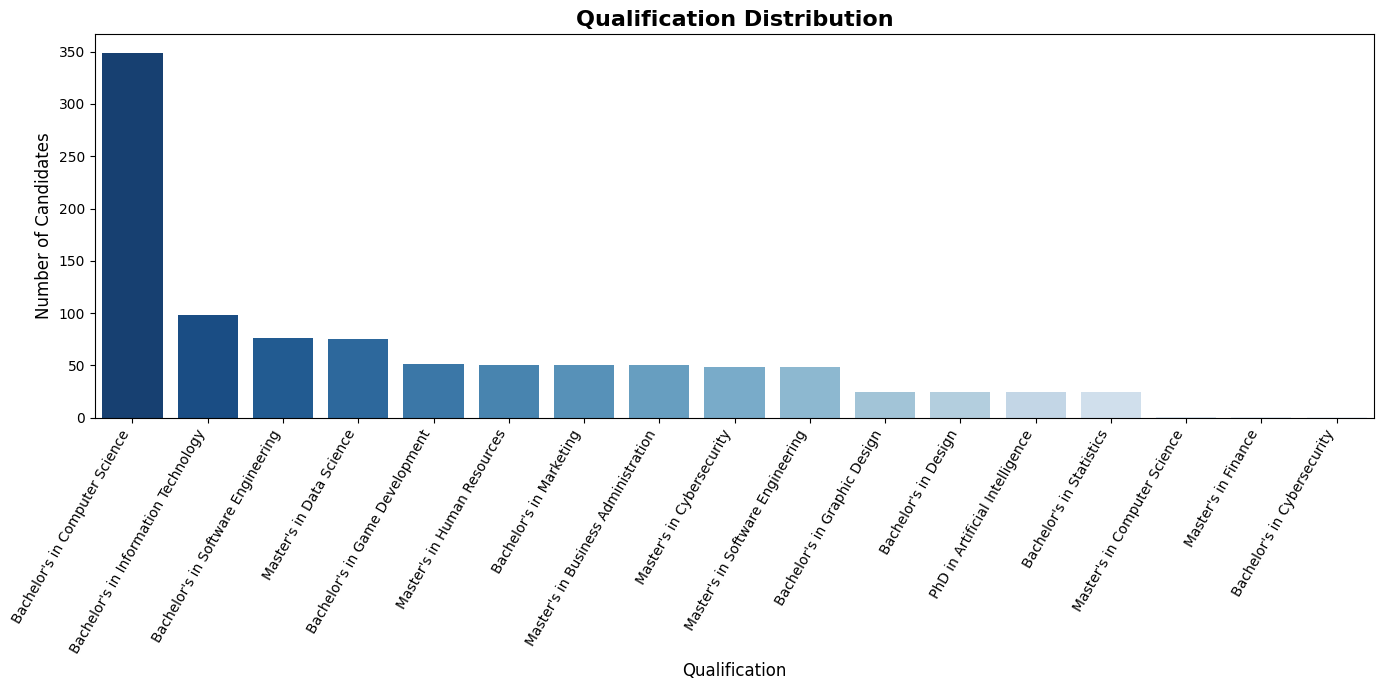

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

sns.countplot(
    data=candidate_df,
    x='qualification',
    order=candidate_df['qualification'].value_counts().index,
    palette='Blues_r'
)

plt.title("Qualification Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Qualification", fontsize=12)
plt.ylabel("Number of Candidates", fontsize=12)

# Rotate and align labels
plt.xticks(rotation=60, ha='right', fontsize=10)

# Adjust layout so labels are not cut off
plt.tight_layout()

plt.show()

**Key Insights:**
- Bachelor's in Computer Science dominates the dataset.
- Information Technology and Software Engineering are the second most common qualifications.
- Advanced degrees (Master's and PhD) are less frequent.
- Several specialized qualifications have very small sample sizes, indicating an imbalanced distribution.


**2.2 Experience Level Distribution**

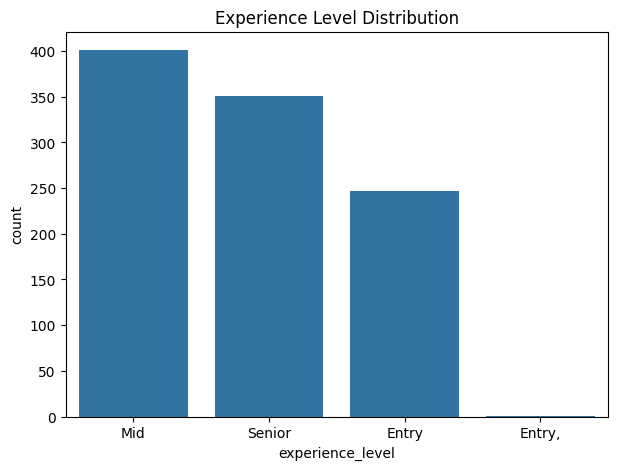

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=candidate_df,
    x='experience_level',
    order=candidate_df['experience_level'].value_counts().index
)

plt.title("Experience Level Distribution")
plt.show()

#### Key Insights
- **Mid-level candidates** have the highest representation, indicating that the dataset is primarily composed of professionals with moderate industry experience.
- **Senior-level candidates** are also well represented, suggesting a substantial pool of experienced professionals.
- **Entry-level candidates** are comparatively fewer, indicating fewer fresh graduates or early-career applicants.
- There appears to be an additional category labeled **"Entry,"**, which likely results from inconsistent data entry (e.g., an extra comma or whitespace). This should be cleaned by merging it with the **"Entry"** category before further analysis.

#**3. Class Distribution**

**3.1 Top Candidate Job roles**

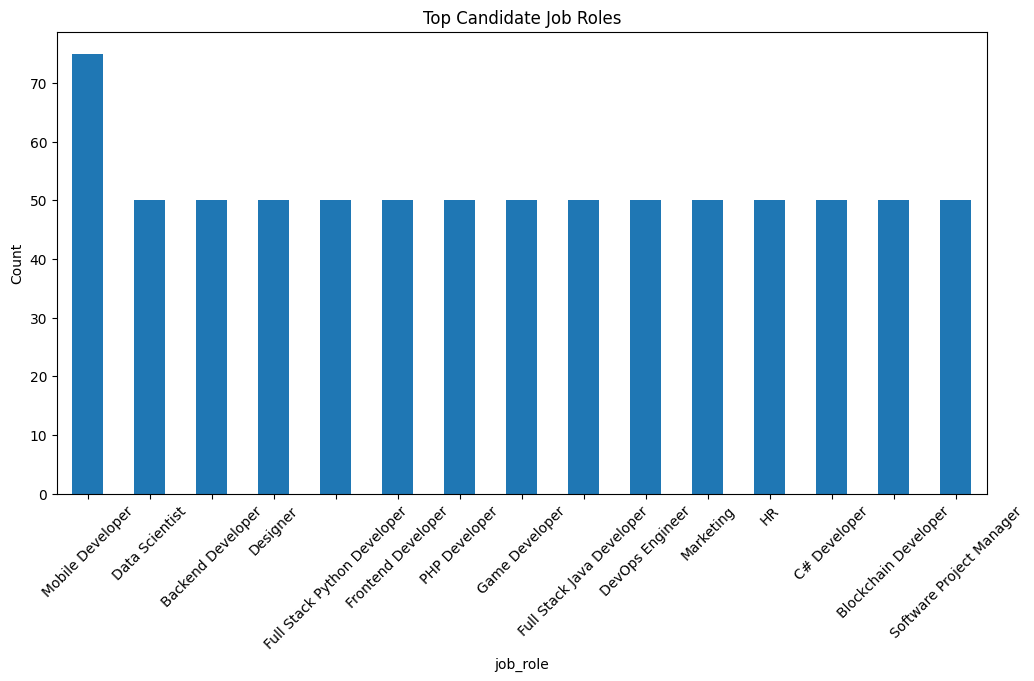

In [ ]:
plt.figure(figsize=(12,6))

candidate_df['job_role'].value_counts().head(15).plot(kind='bar')

plt.title("Top Candidate Job Roles")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### Key Insights
- **Mobile Developer** has the highest number of candidates, making it the dominant job role in the dataset.
- Roles such as **Data Scientist**, **Backend Developer**, **Designer**, **Full Stack Python Developer**, **Frontend Developer**, **PHP Developer**, **Game Developer**, **Full Stack Java Developer**, **DevOps Engineer**, **Marketing**, **HR**, **C# Developer**, **Blockchain Developer**, and **Software Project Manager** have similar frequencies.
- The relatively uniform distribution across most job roles suggests that the dataset was designed to include a diverse range of professions with balanced representation.
- The slight dominance of Mobile Developers may indicate higher demand or greater availability of candidates in mobile application development.

#**4. Missing Value Analysis**

In [ ]:
candidate_df.isna().sum()

,0
candidate_id,0
skills,0
qualification,0
experience_level,0
job_role,0


No missing values in the dataset

#**5. Duplicate Analysis**

In [ ]:
duplicates = candidate_df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


No duplicates in the datasets

# **EDA For Job Postings**

#**1. Dataset Summary Statistics**

In [ ]:
# Dataset shape
print("Shape:", job_df.shape)

Shape: (123849, 31)


**Drop the unnecessary columns for the Job datasets**

In [ ]:
drop_cols = [
    "company_id", "job_posting_url", "application_url", "posting_domain",
    "zip_code", "fips", "closed_time", "original_listed_time",
    "remote_allowed", "views", "applies", "expiry", "sponsored",
    "currency", "pay_period", "compensation_type"
]

job_df = job_df.drop(columns=drop_cols)

In [ ]:
# Data types and non-null values
job_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 15 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   location                    123849 non-null  object 
 6   med_salary                  6280 non-null    float64
 7   min_salary                  29793 non-null   float64
 8   formatted_work_type         123849 non-null  object 
 9   application_type            123849 non-null  object 
 10  formatted_experience_level  94440 non-null   object 
 11  skills_desc                 2439 non-null    object 
 12  listed_time                 123849 non-null  float64
 13  work_type     

In [ ]:
# Summary statistics
job_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_id,123849.0,NaN,NaN,NaN,3896402138.074615,84043545.161881,921716.0,3894586595.0,3901998406.0,3904707077.0,3906267224.0
company_name,122130,24428,Liberty Healthcare and Rehabilitation Services,1108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,123849,72521,Sales Manager,673,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,123842,107827,Position Summary: Our Sales Manager has managi...,474,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max_salary,29793.0,NaN,NaN,NaN,91939.423461,701110.138622,1.0,48.28,80000.0,140000.0,120000000.0
location,123849,8526,United States,8125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
med_salary,6280.0,NaN,NaN,NaN,22015.619876,52255.873846,0.0,18.94,25.5,2510.5,750000.0
min_salary,29793.0,NaN,NaN,NaN,64910.847434,495973.793504,1.0,37.0,60000.0,100000.0,85000000.0
formatted_work_type,123849,7,Full-time,98814,NaN,NaN,NaN,NaN,NaN,NaN,NaN
application_type,123849,4,OffsiteApply,84607,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
job_df.columns

Index(['job_id', 'company_name', 'title', 'description', 'max_salary',
       'location', 'med_salary', 'min_salary', 'formatted_work_type',
       'application_type', 'formatted_experience_level', 'skills_desc',
       'listed_time', 'work_type', 'normalized_salary'],
      dtype='object')

## Dataset Overview

| Property | Value |
|----------|-------|
| **Total Features** | 14 |
| **Total Sample** | 123849 |
| **Numerical Features** | job_id, listed_time, normalized_salary |
| **Categorical Features** | company_name, pay_period, location, formatted_work_type, application_type, formatted_experience_level, work_type, compensation_type |
| **Text Features** | title, description, skills_desc |
| **Primary Identifier** | job_id |


#**2. Feature Distributions**

**2.1 Top 15 Job titles**

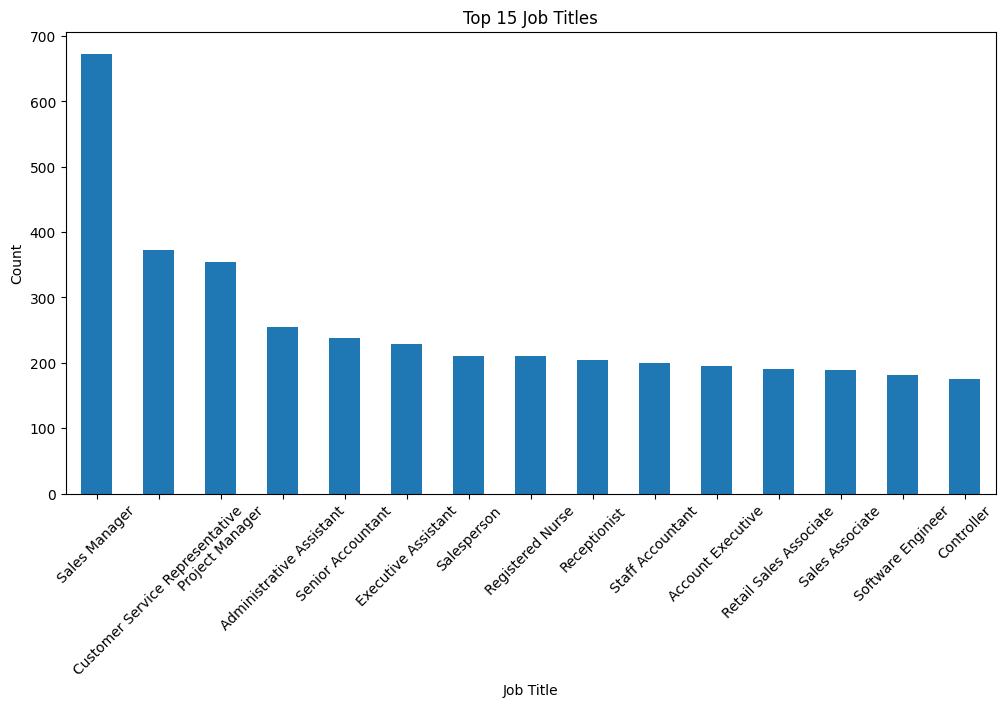

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

job_df['title'].value_counts().head(15).plot(kind='bar')

plt.title("Top 15 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

### **Insights**

- The distribution of job titles is **highly imbalanced**, with **Sales Manager** being the most frequently advertised role, having approximately **670 job postings**. This indicates a significantly higher demand compared to other positions.

- Technical positions such as **Software Engineer** appear among the top 15 job titles but with fewer postings than sales and administrative roles. This suggests that while software engineering opportunities are present, the dataset contains a broader mix of industries rather than being exclusively focused on IT jobs.

- The noticeable difference in posting frequencies between the top-ranked job title and the remaining roles highlights a **class imbalance** in the dataset. This imbalance should be considered during model development, as prediction models may become biased toward more frequently occurring job titles if appropriate balancing techniques are not applied.

**2.2 Experience Level Distribution**

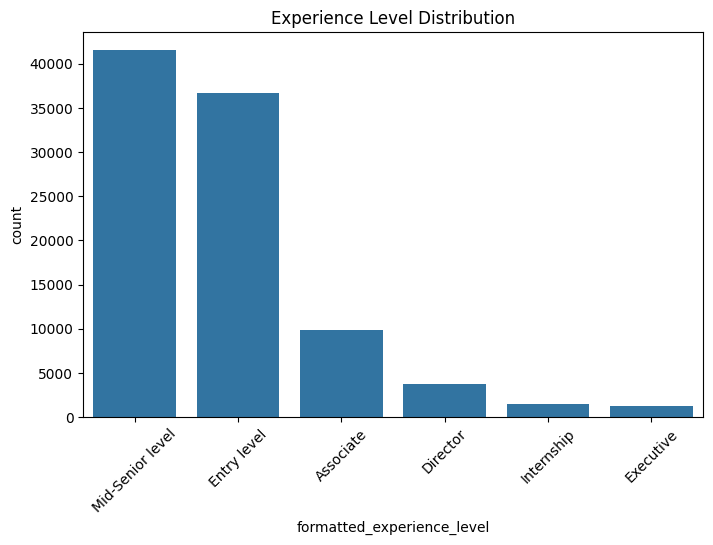

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=job_df,
    x='formatted_experience_level',
    order=job_df['formatted_experience_level'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Experience Level Distribution")

plt.show()

### **Insights**

- The majority of job postings are targeted toward **Mid-Senior Level** and **Entry Level** professionals, indicating that employers primarily seek candidates with either foundational experience or established industry expertise.

- **Associate** and **Director** positions are available in moderate numbers, while **Internship** and **Executive** roles account for only a small proportion of the postings, reflecting lower hiring demand for these experience levels.

- The distribution is **imbalanced**, with Mid-Senior and Entry Level positions dominating the dataset. This imbalance should be considered during model development, as recommendation or classification models may otherwise favor the more frequently represented experience levels.

**2.3 Employment type Distribution**

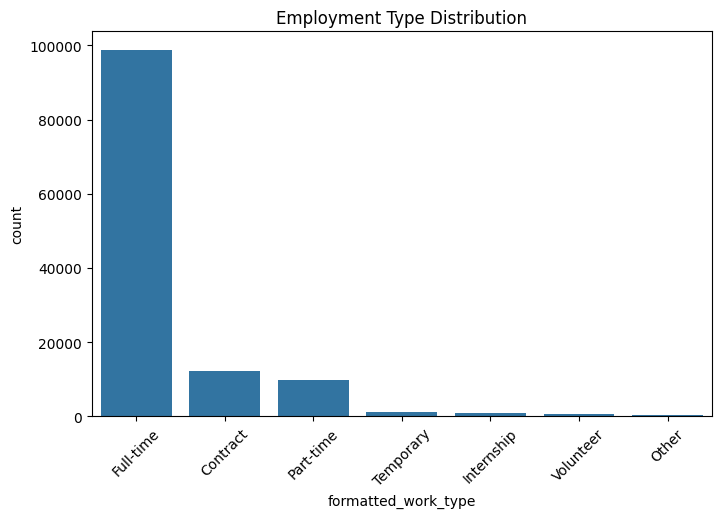

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=job_df,
    x='formatted_work_type',
    order=job_df['formatted_work_type'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Employment Type Distribution")

plt.show()

### **Insights**

- **Full-time positions** dominate the dataset by a large margin, accounting for the vast majority of job postings. This indicates that employers primarily seek candidates for permanent, long-term employment.

- **Contract** and **Part-time** roles are the next most common employment types, but they represent a much smaller share compared to full-time positions. Temporary, internship, volunteer, and other employment types occur only infrequently.

- The distribution is **highly imbalanced**, with full-time jobs significantly outnumbering all other employment types. This suggests that recommendation models trained on this dataset may naturally prioritize full-time opportunities unless measures are taken to account for the underrepresented employment categories.

#**3. Class Distribution**




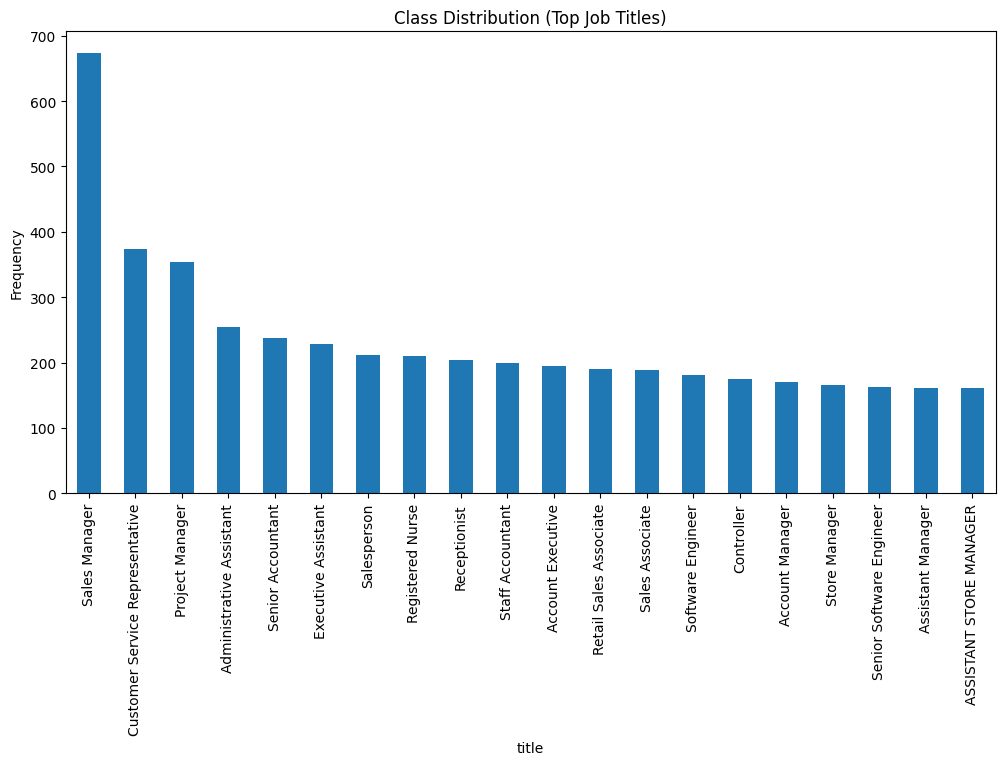

In [ ]:
plt.figure(figsize=(12,6))

job_df['title'].value_counts().head(20).plot(kind='bar')

plt.title("Class Distribution (Top Job Titles)")
plt.ylabel("Frequency")

plt.show()

### **Insights**

- The class distribution is **highly skewed**, with **Sales Manager** being the most frequent job title, followed by **Customer Service Representative** and **Project Manager**. This indicates that these roles have the highest hiring demand in the dataset.

- Administrative, finance, retail, and software-related positions are also well represented, demonstrating that the dataset covers a diverse range of industries and occupations rather than focusing on a single domain.

- The noticeable imbalance in job title frequencies suggests that machine learning models trained on this dataset may become biased toward the most common job classes. Therefore, techniques such as class weighting, oversampling, or balanced evaluation metrics should be considered during model development.

#**4. Missing Value Analysis**

In [ ]:
missing = job_df.isnull().sum().sort_values(ascending=False)

print(missing)

skills_desc                   121410
med_salary                    117569
max_salary                     94056
min_salary                     94056
normalized_salary              87776
formatted_experience_level     29409
company_name                    1719
description                        7
location                           0
job_id                             0
title                              0
application_type                   0
formatted_work_type                0
listed_time                        0
work_type                          0
dtype: int64


## The Columns that contains missing datasets are
1.skills_desc                   
2.pay_period                    
3.normalized_salary              
4.compensation_type             
5.formatted_experience_level     
6.company_name                   
7.description

# **5. Duplicate Analysis**

In [ ]:
duplicates = job_df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


No duplicates in this datasets

#**6. Outlier Analysis**

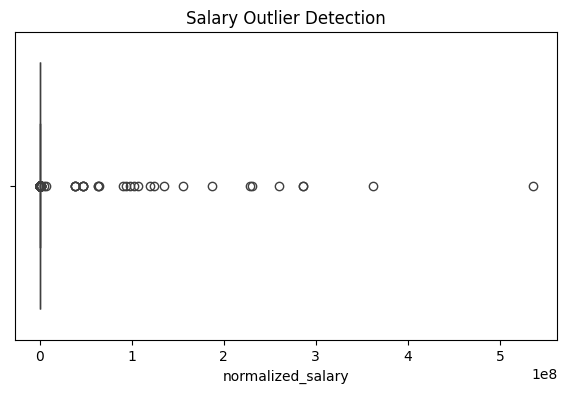

In [ ]:
plt.figure(figsize=(7,4))

sns.boxplot(
    x=job_df['normalized_salary']
)

plt.title("Salary Outlier Detection")

plt.show()

### **Insights**

- The boxplot shows that **most salary values are concentrated within a relatively low range**, while several observations lie far above the upper whisker. These points represent high-paying positions that are considered statistical outliers.

- The salary distribution is **positively (right) skewed**, indicating that although most job postings offer moderate salaries, a small number of positions provide exceptionally high compensation.

- These outliers are likely to correspond to **senior, executive, or highly specialized roles**. Instead of removing them immediately, they should be carefully evaluated, as they may represent valid observations that are important for salary prediction and job recommendation models.

# **7. Correlation Analysis**

**7.1 Correlation Analysis of Numerical Features**

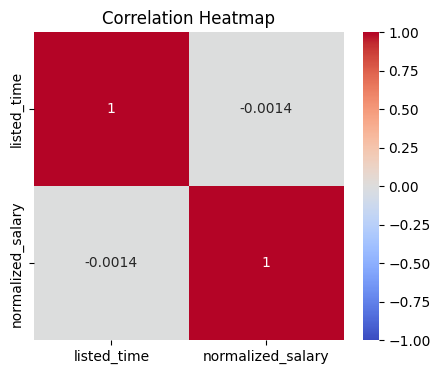

In [ ]:
corr = job_df[
    ['listed_time','normalized_salary']
].corr()

plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap")

plt.show()

### **Insights**

- The correlation heatmap shows an almost **zero correlation (-0.0014)** between **listed_time** and **normalized_salary**, indicating that the time a job was listed has virtually no linear relationship with the salary offered.

- The diagonal values of **1.0** represent the perfect correlation of each variable with itself, which is expected in any correlation matrix.

- Since the dataset contains only two numerical features and their correlation is negligible, salary appears to be influenced by other factors such as **job title, experience level, company, location, and employment type**, rather than the job posting date. These categorical features are therefore likely to provide more predictive value during model development.

**7.2 Experience Level vs Employment Type Analysis**

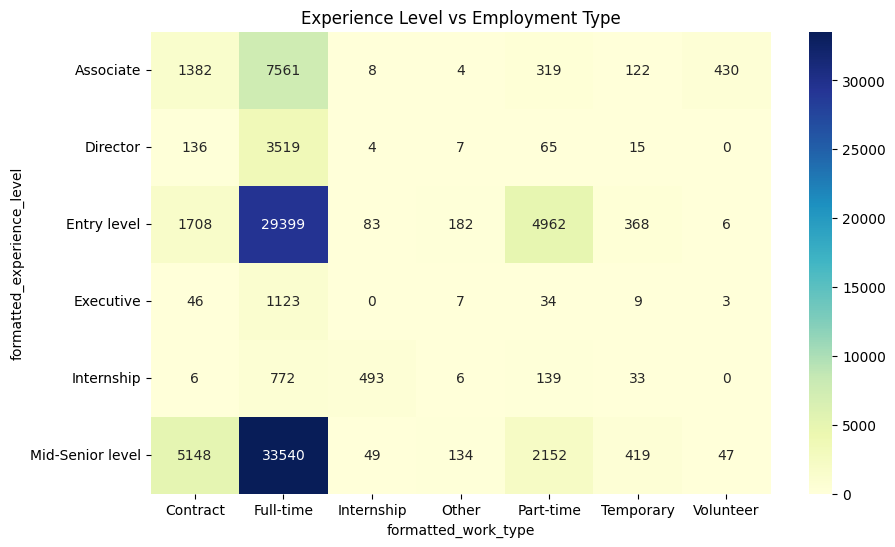

In [ ]:
cross = pd.crosstab(
    job_df['formatted_experience_level'],
    job_df['formatted_work_type']
)

plt.figure(figsize=(10,6))

sns.heatmap(
    cross,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Experience Level vs Employment Type")

plt.show()

### **Insights**

- **Full-time employment** is the dominant employment type across all experience levels. The highest number of postings is observed for **Mid-Senior Level** (33,540) and **Entry Level** (29,399), indicating that organizations primarily recruit experienced professionals and new graduates for permanent positions.

- **Part-time** and **Contract** opportunities are available across most experience levels but occur in significantly lower numbers compared to full-time roles. Entry-level candidates have the highest number of part-time positions (4,962), while Mid-Senior Level candidates have the highest number of contract positions (5,148).

- **Internship**, **Temporary**, **Volunteer**, and **Other** employment types represent only a small proportion of the dataset. Internship positions are naturally concentrated within the **Internship** and **Entry Level** categories, reflecting hiring practices for students and early-career professionals.

### **Dataset Comparison & Column Manipulation Plan**

**Goal:** Identify how the Candidate dataset and Job Postings dataset differ, and which columns must be manipulated to enable ranking jobs against candidates.

---

#### **1. Category-Level Comparison of Matching Columns**

| Aspect | Candidate side | Job side | Mismatch |
|---|---|---|---|
| **Experience** | `experience_level` — 4 unique values (Entry, Junior, Mid, Senior); top = "Mid" (401/1000) | `formatted_experience_level` — 6 unique values (Internship, Entry level, Associate, Mid-Senior level, Director, Executive); top = "Mid-Senior level"; ~29,000 missing rows | Different label sets and granularity; candidate side also has a stray `"Entry, "` typo |
| **Role / Title** | `job_role` — 22 unique values, clean controlled vocabulary (e.g. "Mobile Developer", top freq 75) | `title` — 72,521 unique values, free text (e.g. "Sales Manager", "Senior Sales Manager – East") | Candidate side is categorical; job side is uncontrolled free text — direct equality matching will fail |
| **Skills** | `skills` — 98 unique combinations, comma-separated (e.g. "PHP, Laravel, MySQL, JavaScript", top freq 25) | `skills_desc` — only 2,439 non-null rows out of 123,849 (98% missing); when present, 2,212 unique free-text sentences | Candidate side is compact and structured; job side is almost entirely empty and unstructured when present |

**Takeaway:** No shared key or common category system exists between the two datasets. Each "equivalent" column pair differs in cardinality, format, or missingness, so ranking cannot be built with a simple join — each pair needs its own manipulation.

---

#### **2. Proposed Manipulation (3 columns per side)**

**A. Experience Level → collapse to one shared scale**
- Clean candidate typo: strip whitespace/trailing commas so `"Entry, "` → `"Entry"`.
- Map job's 6 categories down to candidate's 4-bucket scale:
  - `Internship` / `Entry level` → `Entry`
  - `Associate` → `Junior`
  - `Mid-Senior level` → `Mid`
  - `Director` / `Executive` → `Senior`
- Fill missing job values with `"Unknown"` instead of dropping (avoids losing ~23% of postings).

**B. Role / Title → map job's free text into candidate's controlled vocabulary**
- Use fuzzy or embedding similarity (e.g. RapidFuzz `token_sort_ratio`, or sentence embeddings + cosine similarity) to score each `title` against the 22 `job_role` labels.
- Store the best match as a new `matched_role` column plus its similarity score.

**C. Skills → build one comparable text field**
- Since `skills_desc` is 98% empty, concatenate `title + skills_desc + description` into a single `job_text` field per posting.
- Keep candidate `skills` as-is.
- Vectorize both with BM25 and compute cosine similarity between each candidate's `skills` and each job's `job_text`.

---


| Aspect | Candidate Side | Job Side | Mismatch |
|--------|----------------|----------|----------|
| **Experience** | `experience_level` — 4 unique values (`Entry`, `Junior`, `Mid`, `Senior`); top = **"Mid"** (401/1000) | `formatted_experience_level` — 6 unique values (`Internship`, `Entry level`, `Associate`, `Mid-Senior level`, `Director`, `Executive`); top = **"Mid-Senior level"**; ~29,000 missing rows | Different label sets and granularity; candidate side also has a stray `"Entry, "` typo. |
| **Role / Title** | `job_role` — 22 unique values, clean controlled vocabulary (e.g., `"Mobile Developer"`; top frequency = 75) | `title` — 72,521 unique values, free text (e.g., `"Sales Manager"`, `"Senior Sales Manager – East"`) | Candidate side is categorical; job side is uncontrolled free text, so direct equality matching will fail. |
| **Skills** | `skills` — 98 unique combinations, comma-separated (e.g., `"PHP, Laravel, MySQL, JavaScript"`; top frequency = 25) | `skills_desc` — only 2,439 non-null rows out of 123,849 (≈98% missing); when present, 2,212 unique free-text sentences | Candidate side is compact and structured; job side is almost entirely empty and unstructured when present. |